In [8]:
with open('untitled.txt','r') as f:
    var=f.read() 
var=var.split() 
d={}
for i in var: 
    if i in d:
        d[i]+=1
    else:
        d[i]=1
print(d)

FileNotFoundError: [Errno 2] No such file or directory: 'untitled.txt'

In [9]:
import pandas as pd


In [10]:
df=pd.read_csv(r"C:\Users\masir\Downloads\coffee_shop_sales2.csv")

In [11]:
df


,Day,Cups Sold,Avg Temp (°C),FootBall Match (Yes/No)
0,Monday,154,24,No
1,Tuesday,143,23,No
2,Wednesday,166,26,No
3,Thursday,142,22,No
4,Friday,203,33,Yes
5,Saturday,214,34,Yes
6,Sunday,202,32,Yes


In [12]:
!pip install pandas

In [13]:
import pandas as pd


In [14]:
df=pd.read_csv(r"C:\Users\masir\Downloads\loan_data_set.csv")

In [15]:
df


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


**Problem Statement**

**About Company**

Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan.

**Problem**


* Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form.
* These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others.
* To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers.``

In [16]:
df['ApplicantIncome'].mean()

5403.459283387622

In [17]:
df['Gender'].value_counts()


Gender
Male      489
Female    112
Name: count, dtype: int64

In [18]:
df['Education'].value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [19]:
pd.crosstab(df['Gender'],df['Loan_Status'])

Loan_Status,N,Y
Gender,,
Female,37,75
Male,150,339


In [20]:
pd.crosstab(df['Loan_Status'],df['Education'])

Education,Graduate,Not Graduate
Loan_Status,,
N,140,52
Y,340,82


In [21]:
pd.crosstab(df['Loan_Status'], [df['Education'], df['Gender']])

Education   Graduate      Not Graduate     
Gender        Female Male       Female Male
Loan_Status                                
N                 31  105            6   45
Y                 61  271           14   68

In [22]:
df.groupby(["Gender","Property_Area"])[['ApplicantIncome','CoapplicantIncome']].max()

ApplicantIncome  CoapplicantIncome
Gender Property_Area                                    
Female Rural                    10000             3683.0
       Semiurban                19484             8980.0
       Urban                    18165            41667.0
Male   Rural                    81000             8333.0
       Semiurban                39999            20000.0
       Urban                    63337            33837.0

In [23]:
df2 = pd.read_csv(r"C:\Users\masir\Downloads\Housing.csv")
df2.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [25]:
df2[["price","area","bedrooms",'bathrooms','stories','parking']].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


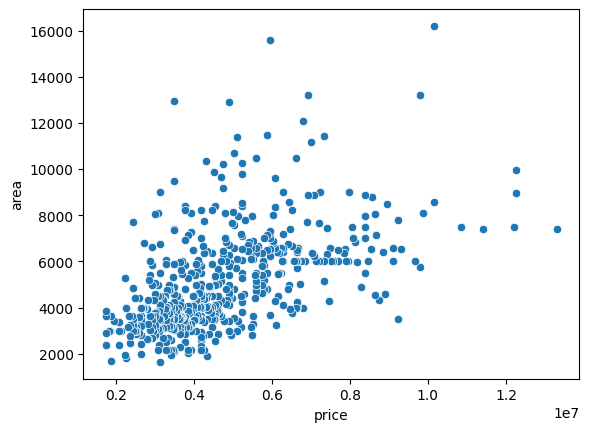

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x='price',y='area',data=df2)
plt.show()

In [27]:
df[['ApplicantIncome','CoapplicantIncome']].corr()

,ApplicantIncome,CoapplicantIncome
ApplicantIncome,1.000000,-0.116605
CoapplicantIncome,-0.116605,1.000000


In [28]:
df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']].corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878
LoanAmount,0.570909,0.188619,1.000000,0.039447
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000


In [29]:
# applicantIncome and coapplicantIncome are independent each other
# ApplicantIncome and loan amount are dependent each other
# applicantIncome and loan_amount_term are independent each other

In [30]:
# if thr r value is bw -1 to -0.5 both the columns are inversionaly proportional
# if thr r value is bw 1 to 0.5 both the columns are directly proportional
# if thr r value is bw -0.5 to 0.5 both the columns are independent each other

In [31]:
 # 0   price             545 non-null    int64 continuous
 # 1   area              545 non-null    int64 continuos
 # 2   bedrooms          545 non-null    int64 discerete 
 # 3   bathrooms         545 non-null    int64 discerete
 # 4   stories           545 non-null    int64 discerete
#  5   parking           545 non-null    int64  discerete

In [32]:
df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [33]:
df2[['price','area','bedrooms','bathrooms','stories','parking']].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


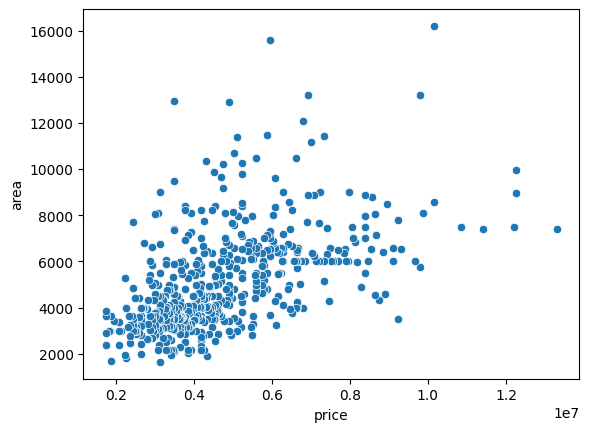

In [34]:
sns.scatterplot(x='price',y='area',data=df2)
plt.show()

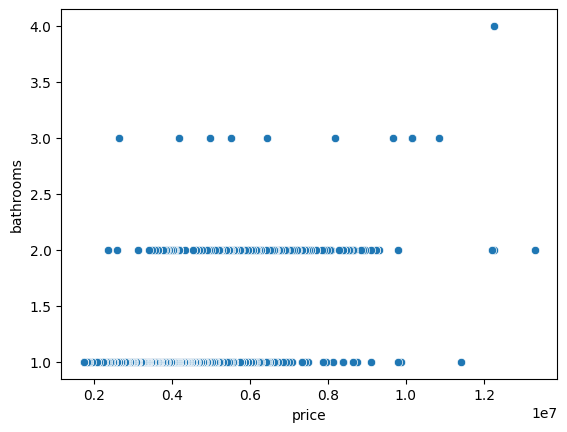

In [35]:
sns.scatterplot(x='price',y='bathrooms',data=df2)
plt.show()

In [36]:
# to prove that both columns basement and area are dependent on each other
# dependent: you should prove that there  is no much difference between the mean of both  the groups(y/n)
# t-Test:Hypothesis Testing -->Number-->decides whether both the columns are dependent or not dependent

In [37]:
# Null Hypothesis : There is no significant difference between means of both the groups(both the columns are dependent on each other)
# Alternative Hypothesis

# if p value is > 0.5 reject the null hypothesis
# if p value is < 0.5 failed to reject the null hypothesis(accept that there is no significant difference between means of both the groups)


# numerical to numerical - pearsons correlation coefficient
# numerical to categorical(2 levels) -- T test
# numerical to categorical (>2levels)--anova(one way)
# categorical to categorical-- chi square


In [38]:
with open('The Discovery.txt','r') as f:
    var=f.read() 
var=var.split() 
chapter_1={}
for i in var: 
    if i in chapter_1:
            chapter_1[i]+=1
    else:
        chapter_1[i]=1
print(chapter_1)

{'Detective': 1, 'Rhea': 3, 'Marshall': 1, 'arrived': 1, 'at': 2, 'the': 11, 'Hale': 1, 'mansion': 1, 'just': 1, 'as': 1, 'morning': 1, 'fog': 1, 'lifted.': 1, 'Victor': 1, 'Hale,': 1, 'a': 5, 'wealthy': 1, 'businessman,': 1, 'was': 4, 'found': 1, 'dead': 1, 'in': 1, 'his': 2, 'study,': 1, 'rare': 1, 'diamond': 1, 'watch': 1, 'missing': 1, 'from': 1, 'wrist.': 1, 'The': 2, 'room': 1, 'showed': 1, 'no': 1, 'signs': 1, 'of': 2, 'forced': 1, 'entry,': 1, 'leaving': 1, 'puzzled': 1, 'about': 2, 'how': 2, 'killer': 1, 'got': 1, 'in.': 1, 'Neighbors': 1, 'whispered': 1, 'strange': 1, 'visitors': 1, 'night': 1, 'before,': 1, 'and': 3, 'security': 1, 'guard': 1, 'mentioned': 1, 'hearing': 1, 'soft': 1, 'click': 1, 'near': 2, 'back': 1, 'door.': 1, 'noticed': 1, 'small,': 1, 'muddy': 1, 'footprint': 1, 'garden': 1, 'fountain.': 1, 'It': 1, 'too': 1, 'delicate': 1, 'to': 4, 'belong': 1, 'house': 1, 'staff,': 1, 'hinting': 1, 'an': 1, 'intruder': 1, 'who': 1, 'moved': 1, 'silently': 1, 'through':

In [39]:
with open('Hidden Motives.txt','r') as f:
    var=f.read() 
var=var.split() 
chapter_2={}
for i in var: 
    if i in chapter_2:
            chapter_2[i]+=1
    else:
        chapter_2[i]=1
print(chapter_2)

{'Rhea': 2, 'began': 1, 'questioning': 1, 'Victorâ€™s': 1, 'family': 1, 'and': 4, 'employees,': 1, 'uncovering': 1, 'layers': 1, 'of': 2, 'tension.': 1, 'His': 1, 'business': 1, 'partner': 1, 'appeared': 1, 'anxious,': 1, 'shifting': 1, 'eyes': 1, 'fidgeting': 1, 'hands.': 1, 'The': 2, 'estranged': 1, 'daughter,': 1, 'on': 1, 'the': 5, 'other': 1, 'hand,': 1, 'sat': 1, 'quietly,': 1, 'almost': 1, 'unnervingly': 1, 'calm.': 1, 'Financial': 1, 'documents': 1, 'revealed': 1, 'a': 4, 'hidden': 1, 'offshore': 1, 'account,': 1, 'housekeeper': 1, 'mentioned': 1, 'threatening': 1, 'letter': 1, 'Victor': 2, 'received': 1, 'days': 1, 'earlier.': 1, 'Motives': 1, 'seemed': 2, 'endless:': 1, 'greed,': 1, 'revenge,': 1, 'jealousy': 1, 'all': 1, 'intertwined': 1, 'in': 2, 'his': 1, 'complicated': 1, 'life.': 1, 'Each': 1, 'person': 1, 'she': 1, 'spoke': 1, 'to': 4, 'have': 1, 'secret': 1, 'they': 1, 'werenâ€™t': 1, 'ready': 1, 'share.': 1, 'Yet,': 1, 'sensed': 1, 'motive': 1, 'was': 2, 'personal,': 

In [40]:
with open('The Discovery.txt','r') as f:
    var=f.read() 
var=var.split() 
chapter_1={}
for i in var: 
    if i in chapter_1:
            chapter_1[i]+=1
    else:
        chapter_1[i]=1
print(chapter_1)

{'Detective': 1, 'Rhea': 3, 'Marshall': 1, 'arrived': 1, 'at': 2, 'the': 11, 'Hale': 1, 'mansion': 1, 'just': 1, 'as': 1, 'morning': 1, 'fog': 1, 'lifted.': 1, 'Victor': 1, 'Hale,': 1, 'a': 5, 'wealthy': 1, 'businessman,': 1, 'was': 4, 'found': 1, 'dead': 1, 'in': 1, 'his': 2, 'study,': 1, 'rare': 1, 'diamond': 1, 'watch': 1, 'missing': 1, 'from': 1, 'wrist.': 1, 'The': 2, 'room': 1, 'showed': 1, 'no': 1, 'signs': 1, 'of': 2, 'forced': 1, 'entry,': 1, 'leaving': 1, 'puzzled': 1, 'about': 2, 'how': 2, 'killer': 1, 'got': 1, 'in.': 1, 'Neighbors': 1, 'whispered': 1, 'strange': 1, 'visitors': 1, 'night': 1, 'before,': 1, 'and': 3, 'security': 1, 'guard': 1, 'mentioned': 1, 'hearing': 1, 'soft': 1, 'click': 1, 'near': 2, 'back': 1, 'door.': 1, 'noticed': 1, 'small,': 1, 'muddy': 1, 'footprint': 1, 'garden': 1, 'fountain.': 1, 'It': 1, 'too': 1, 'delicate': 1, 'to': 4, 'belong': 1, 'house': 1, 'staff,': 1, 'hinting': 1, 'an': 1, 'intruder': 1, 'who': 1, 'moved': 1, 'silently': 1, 'through':

In [41]:
with open('The Breakthrough.txt','r') as f:
    var=f.read() 
var=var.split() 
chapter_3={}
for i in var: 
    if i in chapter_3:
            chapter_3[i]+=1
    else:
        chapter_3[i]=1
print(chapter_3)

{'A': 1, 'lab': 1, 'report': 1, 'arrived,': 1, 'revealing': 1, 'fingerprints': 1, 'on': 1, 'the': 14, 'watch': 1, 'case.': 1, 'They': 1, 'didnâ€™t': 1, 'belong': 1, 'to': 4, 'Victor,': 1, 'but': 1, 'someone': 1, 'he': 1, 'trusted': 1, 'deeply.': 1, 'Meanwhile,': 1, 'surveillance': 1, 'footage': 1, 'showed': 1, 'a': 3, 'shadowy': 1, 'figure': 1, 'leaving': 1, 'mansion': 1, 'late': 1, 'at': 1, 'night,': 2, 'face': 1, 'hidden': 1, 'by': 1, 'security': 1, 'cameraâ€™s': 1, 'poor': 1, 'angle.': 1, 'The': 1, 'footprint': 1, 'in': 1, 'garden': 1, 'was': 1, 'traced': 1, 'rare': 1, 'designer': 1, 'shoe,': 1, 'narrowing': 1, 'suspect': 1, 'list': 1, 'significantly.': 1, 'Every': 1, 'lead': 1, 'pointed': 1, 'toward': 1, 'daughter,': 1, 'whose': 1, 'calm': 1, 'demeanor': 1, 'now': 1, 'seemed': 1, 'calculated.': 1, 'Rhea': 2, 'began': 1, 'questioning': 1, 'whether': 1, 'appearances': 1, 'could': 2, 'be': 1, 'deceiving,': 1, 'or': 1, 'if': 1, 'daughter': 1, 'had': 2, 'indeed': 1, 'orchestrated': 1, '

In [42]:
with open('The Confession.txt','r') as f:
    var=f.read() 
var=var.split() 
chapter_4={}
for i in var: 
    if i in chapter_4:
            chapter_4[i]+=1
    else:
        chapter_4[i]=1
print(chapter_4)

{'Rhea': 2, 'gathered': 1, 'all': 1, 'the': 10, 'suspects': 1, 'in': 2, 'grand': 1, 'drawing': 1, 'room,': 1, 'each': 1, 'one': 1, 'tense': 1, 'and': 3, 'wary.': 1, 'She': 1, 'laid': 1, 'out': 1, 'evidence': 1, 'carefully,': 1, 'watching': 1, 'reactions': 1, 'for': 1, 'signs': 1, 'of': 4, 'guilt.': 1, 'The': 2, 'air': 1, 'was': 3, 'thick': 1, 'with': 2, 'suspense': 1, 'as': 1, 'accusations': 1, 'began': 1, 'to': 4, 'fly.': 1, 'Finally,': 1, 'she': 1, 'focused': 1, 'on': 2, 'business': 1, 'partner,': 1, 'who': 1, 'tried': 1, 'maintain': 1, 'composure': 1, 'but': 2, 'faltered': 1, 'under': 1, 'her': 1, 'steady': 1, 'gaze.': 1, 'Faced': 1, 'meticulous': 1, 'reconstruction': 1, 'nightâ€™s': 1, 'events,': 1, 'he': 1, 'confessed:': 1, 'greed': 1, 'jealousy': 1, 'had': 1, 'driven': 1, 'him': 1, 'murder': 1, 'Victor,': 1, 'framing': 1, 'daughter': 1, 'hide': 1, 'his': 1, 'tracks.': 1, 'Justice': 1, 'served,': 1, 'yet': 1, 'mansion': 1, 'felt': 1, 'colder': 1, 'than': 1, 'before.': 1, 'reflecte

In [43]:

pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 1000)       

table_data = [
    {'Chapter Number': 1, 'Chapter Name': 'The Discovery', 'Description': chapter_1},
    {'Chapter Number': 2, 'Chapter Name': 'Hidden Motives', 'Description': chapter_2},
    {'Chapter Number': 3, 'Chapter Name': 'The Breakthrough', 'Description': chapter_3},
    {'Chapter Number': 4, 'Chapter Name': 'The Confession', 'Description': chapter_4}
]

df = pd.DataFrame(table_data)

print(df)

   Chapter Number      Chapter Name                                        Description
0               1     The Discovery  {'Detective': 1, 'Rhea': 3, 'Marshall': 1, 'ar...
1               2    Hidden Motives  {'Rhea': 2, 'began': 1, 'questioning': 1, 'Vic...
2               3  The Breakthrough  {'A': 1, 'lab': 1, 'report': 1, 'arrived,': 1,...
3               4    The Confession  {'Rhea': 2, 'gathered': 1, 'all': 1, 'the': 10...


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Chapter Number  4 non-null      int64 
 1   Chapter Name    4 non-null      object
 2   Description     4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes


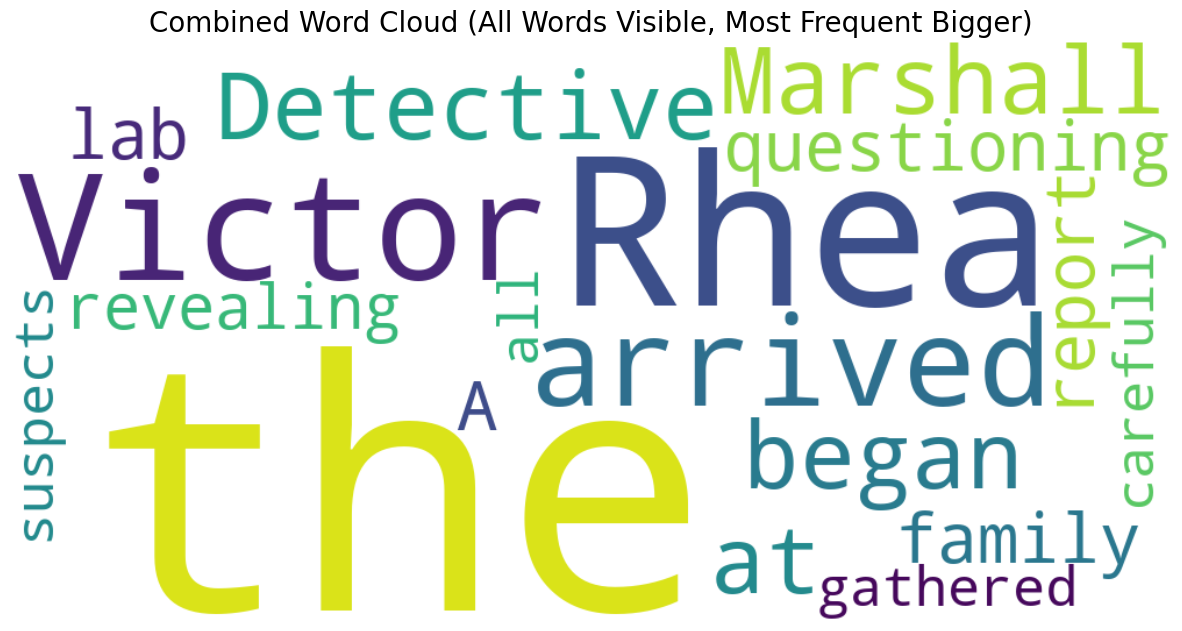

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Chapter word counts
chapter_1 = {'Detective': 1, 'Rhea': 3, 'Marshall': 1, 'arrived': 1, 'at': 1, 'the': 10}
chapter_2 = {'Rhea': 2, 'began': 1, 'questioning': 1, 'Victor': 3, 'family': 1, 'the': 8}
chapter_3 = {'A': 1, 'lab': 1, 'report': 1, 'arrived': 1, 'revealing': 1, 'the': 7}
chapter_4 = {'Rhea': 2, 'gathered': 1, 'all': 1, 'the': 10, 'suspects': 1, 'carefully':1}

# Combine all chapters
all_chapters = [chapter_1, chapter_2, chapter_3, chapter_4]

# Sum frequencies
total_freq = Counter()
for chapter in all_chapters:
    total_freq.update(chapter)

# Optional: scale down very frequent words to avoid tiny words disappearing
max_freq = max(total_freq.values())
scaled_freq = {word: freq/max_freq for word, freq in total_freq.items()}

# Generate the word cloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200,
    stopwords=None
)
wc.generate_from_frequencies(scaled_freq)

# Display
plt.figure(figsize=(15,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Combined Word Cloud (All Words Visible, Most Frequent Bigger)', fontsize=20)
plt.show()


In [46]:
import random
import numpy as np
a=[random.randint(1,100) for i in range(10)]
a


[53, 67, 33, 51, 29, 31, 99, 7, 10, 93]

In [47]:
nparr=np.array(a)
a

[53, 67, 33, 51, 29, 31, 99, 7, 10, 93]

In [48]:
# to learn how to create numpy arrays and interact with arrays
# we dont have any data as of now
#you should also learn how to access it

In [49]:
data={'salaries':[random.randint(10000,20000)for i in range(30)]}
data

{'salaries': [12655,
  13432,
  18635,
  10987,
  14008,
  15065,
  13935,
  14063,
  17006,
  19306,
  16412,
  15289,
  15284,
  16546,
  10162,
  16726,
  17615,
  19540,
  12093,
  11083,
  15246,
  15177,
  11983,
  17433,
  18172,
  18418,
  11282,
  14827,
  12796,
  13008]}

In [50]:
arr=np.arange(3,31,3)
print(arr)

[ 3  6  9 12 15 18 21 24 27 30]


In [51]:
np.random.randint(5000,8000,[10,3])

array([[5495, 6151, 6032],
       [7583, 6289, 6529],
       [6705, 6329, 7531],
       [7013, 5839, 7520],
       [6135, 6101, 7053],
       [5009, 7339, 6363],
       [7319, 6754, 5986],
       [7802, 7771, 5449],
       [6244, 6999, 6035],
       [6532, 6828, 7738]])

In [52]:
# np.random.rand-->creating datapoints from a random distribution between 0 and 1
# np.random.randn-->creating normalized datapoints from a random distribution between 0 and 1
# np.random.uniform-->creating datapoints from a uniform distribution


In [53]:
# let us learn how to create a numpy array from a given file
# create file with some random data
# np.genfromtext -->differentdatatypes (float,int,string)
# np.loadtxt --> numbers in the data
# np.fromfile -->numbers in the data


In [54]:
# let us create a file and store a tabular dataset in that

# .csv - comma seperated value
# .txt - every line using comma

# age gender salary
# v1   v2     v3
#  v4   v5     v6

In [55]:
path=r"C:\Users\masir\OneDrive\Desktop\file"
categories=['male','female','other']

In [56]:
with open (path +'/data.txt','w') as file :
    file.write('age,')
    file.write('salary,')
    file.write('\n')
    for i in range(3):
        age=random.randint(10,20)
        gender=random.choice(categories)
        salary=random.randint(1000,2000)
        file.write(f'{age},{salary}\n')
    file.close()
        
        

In [57]:
np.loadtxt(path +'/data.txt',skiprows=1,delimiter=',')
# ensure that the data is the format of numbers
# you will have to skip the first row
# delimeter=','

array([[  18., 1809.],
       [  15., 1903.],
       [  19., 1541.]])

In [58]:
# as you know that every dataset can contain multiple datatypes
# np.genfromtxt
# using numpy i will load the exisiting file
arr=np.genfromtxt(r"C:\Users\masir\Downloads\Housing.csv",delimiter=',',skip_header=1,encoding='utf-8',
             dtype=None) #it automically recognizes the data type


In [59]:
print(arr)

[(13300000,  7420, 4, 2, 3, 'yes', 'no', 'no', 'no', 'yes', 2, 'yes', 'furnished')
 (12250000,  8960, 4, 4, 4, 'yes', 'no', 'no', 'no', 'yes', 3, 'no', 'furnished')
 (12250000,  9960, 3, 2, 2, 'yes', 'no', 'yes', 'no', 'no', 2, 'yes', 'semi-furnished')
 (12215000,  7500, 4, 2, 2, 'yes', 'no', 'yes', 'no', 'yes', 3, 'yes', 'furnished')
 (11410000,  7420, 4, 1, 2, 'yes', 'yes', 'yes', 'no', 'yes', 2, 'no', 'furnished')
 (10850000,  7500, 3, 3, 1, 'yes', 'no', 'yes', 'no', 'yes', 2, 'yes', 'semi-furnished')
 (10150000,  8580, 4, 3, 4, 'yes', 'no', 'no', 'no', 'yes', 2, 'yes', 'semi-furnished')
 (10150000, 16200, 5, 3, 2, 'yes', 'no', 'no', 'no', 'no', 0, 'no', 'unfurnished')
 ( 9870000,  8100, 4, 1, 2, 'yes', 'yes', 'yes', 'no', 'yes', 2, 'yes', 'furnished')
 ( 9800000,  5750, 3, 2, 4, 'yes', 'yes', 'no', 'no', 'yes', 1, 'yes', 'unfurnished')
 ( 9800000, 13200, 3, 1, 2, 'yes', 'no', 'yes', 'no', 'yes', 2, 'yes', 'furnished')
 ( 9681000,  6000, 4, 3, 2, 'yes', 'yes', 'yes', 'yes', 'no', 2,

In [60]:
arr.size

545

In [61]:
print(arr[0])

(13300000, 7420, 4, 2, 3, 'yes', 'no', 'no', 'no', 'yes', 2, 'yes', 'furnished')


In [62]:
total_count=[]
for i in range(len(arr)):
    if arr[i][5]=='yes' or  arr[i][5]=='no':
        total_count.append(arr[i][5])
    else:
        total_count.append('missing')

In [63]:
print(total_count)

['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes'

In [64]:
# univariate Analysis
print(total_count.count('yes'))
print(total_count.count('no'))

468
77


In [65]:
# integer
# signed --> +ve and -ve
# np.int8
# np.int16
# np.int32
# np.int64
# unsigned --> +ve
# np.uint8
# np.uint16
# np.uint32
# np.uint64

In [66]:
import numpy as np
var=np.array([1,2,3])
var.dtype

dtype('int32')

In [67]:
# Choosing the right dtype saves memory — crucial when working with large datasets or arrays with millions of elements.
# Using simpler types  can make computations faster.
# arrays are stored in the contigouos memory so we can access instantly where list stores refernces every we need to access we need to jump different loactions

In [68]:
# how to calculate the memory occupied by the numpy array
# array.size--> number of elements in an array
# array.itemsize--> number of bytes occupied by each element in an array
# array.nbytes--> size*itemsize  --> number of bytes occupied by entire array

In [69]:
array=np.array([1,2,3])
print(array.size,array.itemsize,array.nbytes)

3 4 12


In [70]:
array=np.array([1,2,3],dtype=np.int64)
print(array.size,array.itemsize,array.nbytes) 

3 8 24


In [71]:
print(bin(50))

0b110010


In [72]:
print(bin(50000))

0b1100001101010000


In [73]:
var1=np.array(500000000)
v1=var1.itemsize

In [74]:
v1-v2

NameError: name 'v2' is not defined

In [ ]:
arr=np.random.randint(0,128,100000000)

In [ ]:
# let us also look into the time consumed by the numpy arrays
import  numpy as np
var1=np.array(arr,dtype=np.int8)
var2=np.array(arr,dtype=np.int16)
var3=np.array(arr,dtype=np.int32)
var4=np.array(arr,dtype=np.int64)

In [ ]:
import time

In [ ]:
start=time.time() 
var1+var1
end=time.time() 
total_time=end-start
print(f'total time taken is {total_time:6f} seconds')

In [ ]:
start=time.time() 
var2+var2
end=time.time() 
total_time=end-start
print(f'total time taken is {total_time:6f} seconds')

In [ ]:
start=time.time() 
var3+var3
end=time.time() 
total_time=end-start
print(f'total time taken is {total_time:6f} seconds')


In [ ]:
start=time.time() 
var4+var4
end=time.time() 
total_time=end-start
print(f'total time taken is {total_time:6f} seconds')

In [ ]:
arr=np.random.randint(130,500,10)
v1=np.array(arr,dtype=np.int8)
v2=np.array(arr,dtype=np.int64)

In [ ]:
print(v1.mean())
print(v2.mean())

In [ ]:

indexes=[i for i in range(len(arr))]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=v1,y=indexes,label='int8')
plt.scatter(x=v2,y=indexes,label='int64')
plt.show()

In [ ]:
# mostly commonly we use int8 for images
import cv2
img=cv2.imread(r"C:\Users\masir\Pictures\_O5A6847.JPG")
img.dtype

In [ ]:
arr=np.array(img)
arr

In [ ]:
a=np.array([-800,20,-40])


In [ ]:
v1=np.array(a,dtype=np.uint8)
v1

In [ ]:
v2=np.array(a,dtype=np.uint64)
v2

In [ ]:
print(v1.var())

In [ ]:
print(v2.var())

In [ ]:
indexes=[i for i in range(len(a))]
plt.scatter(x=v1,y=indexes,label='uint64')
plt.scatter(x=v2,y=indexes,label='uint8')
plt.legend()
plt.show()

In [ ]:
# to prevent the overflowing -->clipping
# clipping requires a array starting clip and ending clip values
# values which are falling less than starting clip turned into starting clip
# and
# values which are falling  after the ending clip are turned into ending clip

In [ ]:
import numpy as np
arr1=np.array(np.arange(1,10)) 
np.clip(arr1,3,8)

In [ ]:
array=np.array(np.random.uniform(1,100))

In [75]:
array.dtype

dtype('int64')

In [76]:
# Speed vs Accuracy 
# ML or Dl performance
# real time project --> faster response and optimal accuracy
# a research or educational project --> slower response and best accuracy

In [77]:
a=np.array(np.arange(100))
print(a.dtype)

int32


In [78]:
b=a.astype(np.int8)
print(a.dtype,a.nbytes)
print(b.dtype,b.nbytes)

int32 400
int8 100


In [79]:
a=np.array([-66,-77,-126,12,44,78])
b=np.clip(a,0,128)
print(b)

[ 0  0  0 12 44 78]


In [80]:
import cv2
import matplotlib.pyplot as plt

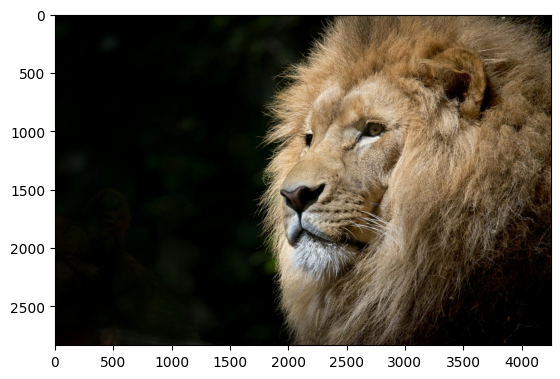

In [81]:
img=cv2.imread(r"C:\Users\masir\Downloads\pexels-pixabay-33045.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [82]:
normalized_img=img/255.0

In [83]:
img.max()

255

In [84]:
img.min()

0

In [85]:
normalized_img.max()

1.0

In [86]:
normalized_img.min()

0.0

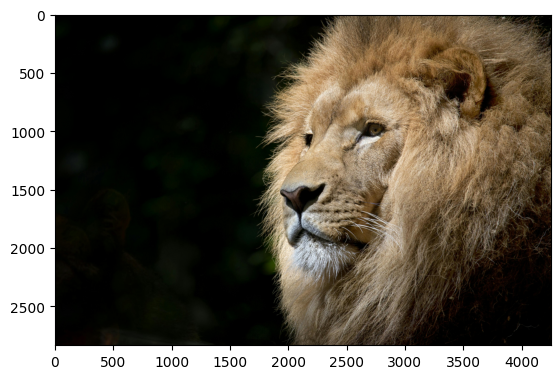

In [87]:
plt.imshow(normalized_img)
plt.show()

In [88]:
bright=normalized_img*1.5
clipping=np.clip(bright,0,1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5].


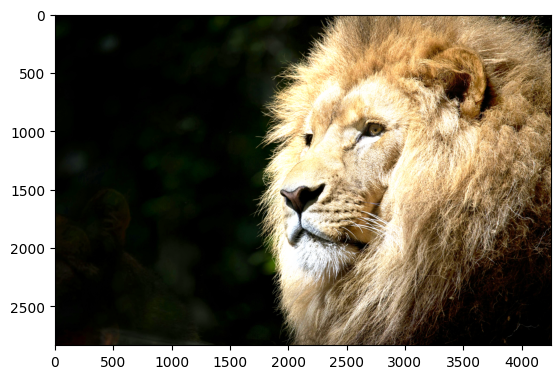

In [89]:
plt.imshow(bright)
plt.show()

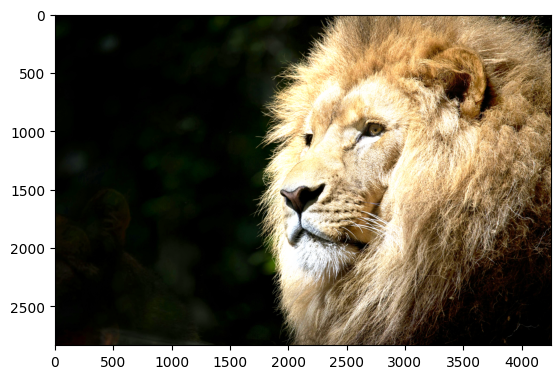

In [90]:
plt.imshow(clipping)
plt.show()

In [91]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
audio_file_path = r"C:\Users\masir\Downloads\bike.mp3"  # Replace with the actual path to your file
y, sr = librosa.load(audio_file_path)
y=y*1.5


In [ ]:
# Strings
# str_ --> text related datapoints:alphabets,words
# unicode_ --> text + emojis

In [92]:
np.array(np.random.choice(['dog','cat','rabbit'],10)) 
# u6 means unicode 6 places was occupied by a word rabbit

array(['dog', 'rabbit', 'dog', 'rabbit', 'cat', 'rabbit', 'cat', 'cat',
       'rabbit', 'dog'], dtype='<U6')

In [93]:
np.array(np.random.choice(['dog','cat','rab'],10)) 
# u3 means unicode 3 places was occupied by a word rab or cat or dog

array(['dog', 'rab', 'cat', 'cat', 'dog', 'cat', 'dog', 'rab', 'cat',
       'rab'], dtype='<U3')

In [95]:
np.array(np.random.choice(['dog','cat','rab'],10),dtype=np.str_) 

array(['dog', 'dog', 'cat', 'rab', 'cat', 'rab', 'dog', 'dog', 'dog',
       'rab'], dtype='<U3')

In [ ]:
# if we want the numpy array to accept int,float,str -->object
# when we are defining only strings --->u(maximum_len of the string)

In [97]:
np.array([1,2,3.5,True],dtype=np.object_)
# A NumPy array with dtype=object can hold multiple data types, treating each element as its own Python object.

array([1, 2, 3.5, True], dtype=object)

In [99]:
np.array(['😙','😙','😙'],dtype=np.unicode_)

array(['😙', '😙', '😙'], dtype='<U1')

In [103]:
arr1=np.array(['1.1','2.2'])
arr2=arr1.astype(np.float64)
arr3=arr2.astype(np.int64)
arr3

array([1, 2], dtype=int64)

In [104]:
arr1=np.array([10,20,30])

In [105]:
print(arr1)

[10 20 30]


In [107]:
array=np.array(np.random.randint(10,50,8))
array

array([48, 11, 33, 21, 45, 38, 47, 33])

In [109]:
array[1:7]

array([11, 33, 21, 45, 38, 47])

In [112]:
mask=array>15

In [113]:
array[mask]

array([48, 33, 21, 45, 38, 47, 33])

In [114]:
array[array>10]

array([48, 11, 33, 21, 45, 38, 47, 33])

In [1]:
# Tabular Data:masking can be used to filter the values based on condition
# Image Data: mask to filter out the unwanted pixels,Binary Image,Edge Detection
# Audio Data: mask to filter the unwanted frequency,loud sound(low pass,filter high) 

In [2]:
import numpy as np


In [7]:
data = np.genfromtxt(
    r"C:\Users\masir\Downloads\Housing.csv", 
    delimiter=',',       
    dtype=None,           
    encoding='utf-8'
)

In [8]:
c=0
dictionary={}
for columns in data[0]:
    dictionary[f'column_{c}']=str(columns)
    c+=1

In [9]:
dictionary

{'column_0': 'price',
 'column_1': 'area',
 'column_2': 'bedrooms',
 'column_3': 'bathrooms',
 'column_4': 'stories',
 'column_5': 'mainroad',
 'column_6': 'guestroom',
 'column_7': 'basement',
 'column_8': 'hotwaterheating',
 'column_9': 'airconditioning',
 'column_10': 'parking',
 'column_11': 'prefarea',
 'column_12': 'furnishingstatus'}

In [10]:
df=data[1:,:]

In [11]:
data

array([['price', 'area', 'bedrooms', ..., 'parking', 'prefarea',
        'furnishingstatus'],
       ['13300000', '7420', '4', ..., '2', 'yes', 'furnished'],
       ['12250000', '8960', '4', ..., '3', 'no', 'furnished'],
       ...,
       ['1750000', '3620', '2', ..., '0', 'no', 'unfurnished'],
       ['1750000', '2910', '3', ..., '0', 'no', 'furnished'],
       ['1750000', '3850', '3', ..., '0', 'no', 'unfurnished']],
      dtype='<U16')

In [13]:
df[:,0]

array(['13300000', '12250000', '12250000', '12215000', '11410000',
       '10850000', '10150000', '10150000', '9870000', '9800000',
       '9800000', '9681000', '9310000', '9240000', '9240000', '9100000',
       '9100000', '8960000', '8890000', '8855000', '8750000', '8680000',
       '8645000', '8645000', '8575000', '8540000', '8463000', '8400000',
       '8400000', '8400000', '8400000', '8400000', '8295000', '8190000',
       '8120000', '8080940', '8043000', '7980000', '7962500', '7910000',
       '7875000', '7840000', '7700000', '7700000', '7560000', '7560000',
       '7525000', '7490000', '7455000', '7420000', '7420000', '7420000',
       '7350000', '7350000', '7350000', '7350000', '7343000', '7245000',
       '7210000', '7210000', '7140000', '7070000', '7070000', '7035000',
       '7000000', '6930000', '6930000', '6895000', '6860000', '6790000',
       '6790000', '6755000', '6720000', '6685000', '6650000', '6650000',
       '6650000', '6650000', '6650000', '6650000', '6629000', '66

In [16]:
avrg_price=df[:,0].astype(np.int32).mean() 

In [17]:
avrg_price

4766729.247706422

In [25]:
houseslessavg=len(df[:,0][df[:,0].astype(np.int32) < avrg_price])
houseslessavg

323

In [26]:
housesmoreavg=len(df[:,0][df[:,0].astype(np.int32) > avrg_price])
housesmoreavg

222

In [27]:
data[:,2]

array(['bedrooms', '4', '4', '3', '4', '4', '3', '4', '5', '4', '3', '3',
       '4', '4', '4', '3', '4', '4', '3', '3', '3', '3', '3', '3', '3',
       '3', '4', '3', '3', '5', '4', '3', '3', '4', '3', '5', '3', '3',
       '4', '3', '4', '3', '3', '3', '4', '4', '3', '3', '3', '3', '3',
       '3', '3', '4', '3', '3', '3', '4', '4', '4', '3', '3', '2', '4',
       '4', '3', '3', '2', '3', '3', '4', '3', '4', '3', '2', '3', '4',
       '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3',
       '5', '3', '2', '3', '3', '4', '3', '3', '3', '3', '4', '3', '3',
       '3', '3', '3', '3', '4', '3', '4', '4', '3', '3', '6', '3', '2',
       '3', '3', '4', '3', '3', '3', '3', '4', '4', '3', '3', '3', '3',
       '3', '3', '3', '4', '3', '3', '3', '3', '4', '4', '3', '3', '3',
       '4', '4', '5', '4', '3', '2', '3', '3', '4', '3', '4', '5', '3',
       '3', '3', '3', '4', '3', '3', '4', '3', '4', '3', '3', '3', '3',
       '2', '4', '4', '3', '3', '3', '4', '3', '4', '3', '3', 

In [28]:
np.unique(df[:,2]) 

array(['1', '2', '3', '4', '5', '6'], dtype='<U16')

In [31]:
unique, counts = np.unique(df[:,2], return_counts=True)
print(unique)   
print(counts)   
# most of the bedrooms have 3 bedrooms -->univarite

['1' '2' '3' '4' '5' '6']
[  2 136 300  95  10   2]


In [33]:
# bivarite analysis
data[1:,[0,5]]

array([['13300000', 'yes'],
       ['12250000', 'yes'],
       ['12250000', 'yes'],
       ...,
       ['1750000', 'yes'],
       ['1750000', 'no'],
       ['1750000', 'yes']], dtype='<U16')

In [37]:
sample=np.take(data[1:],[2,5],axis=1) 

In [38]:
sample

array([['4', 'yes'],
       ['4', 'yes'],
       ['3', 'yes'],
       ...,
       ['2', 'yes'],
       ['3', 'no'],
       ['3', 'yes']], dtype='<U16')

In [85]:
col1=df[:,2]
col2=df[:,5]
print(col1.shape)
print(col2.shape)

(545,)
(545,)


In [86]:
sample1=np.vstack((col1,col2))
print(sample1) 

[['4' '4' '3' ... '2' '3' '3']
 ['yes' 'yes' 'yes' ... 'yes' 'no' 'yes']]


In [87]:
np.concatenate((col1,col2),axis=0)  

array(['4', '4', '3', ..., 'yes', 'no', 'yes'], dtype='<U16')

In [88]:
mask = (sample1[0].astype(np.int32) > 1) & (sample1[1] == 'yes')
result = sample1[:, mask]
print(result)


[['4' '4' '3' '4' '4' '3' '4' '5' '4' '3' '3' '4' '4' '4' '3' '4' '4' '3'
  '3' '3' '3' '3' '3' '3' '3' '4' '3' '3' '5' '4' '3' '3' '4' '3' '5' '3'
  '3' '4' '3' '4' '3' '3' '3' '4' '4' '3' '3' '3' '3' '3' '3' '3' '4' '3'
  '3' '3' '4' '4' '4' '3' '3' '2' '4' '4' '3' '3' '2' '3' '3' '4' '3' '4'
  '3' '2' '3' '4' '3' '3' '3' '3' '3' '3' '3' '3' '3' '3' '3' '3' '3' '5'
  '3' '2' '3' '3' '4' '3' '3' '3' '3' '4' '3' '3' '3' '3' '3' '3' '4' '3'
  '4' '4' '3' '3' '6' '3' '2' '3' '3' '4' '3' '3' '3' '3' '4' '4' '3' '3'
  '3' '3' '3' '3' '3' '4' '3' '3' '3' '3' '4' '4' '3' '3' '3' '4' '4' '4'
  '3' '2' '3' '3' '4' '3' '4' '5' '3' '3' '3' '3' '3' '3' '4' '3' '4' '3'
  '3' '3' '3' '2' '4' '3' '3' '3' '4' '3' '4' '3' '3' '3' '3' '3' '3' '3'
  '3' '2' '3' '2' '4' '3' '3' '2' '3' '4' '3' '3' '3' '3' '2' '4' '3' '3'
  '2' '3' '3' '3' '3' '3' '4' '4' '2' '3' '3' '3' '2' '3' '4' '4' '2' '3'
  '2' '2' '3' '2' '3' '4' '2' '3' '3' '3' '3' '3' '2' '3' '4' '3' '3' '3'
  '3' '3' '3' '3' '3' '4' '2' '4' '3' 

In [89]:
sample2=df[:,[0,2]] 

In [90]:
sample2


array([['13300000', '4'],
       ['12250000', '4'],
       ['12250000', '3'],
       ...,
       ['1750000', '2'],
       ['1750000', '3'],
       ['1750000', '3']], dtype='<U16')

In [91]:
sample3=sample2[sample2[:,1].astype(np.int32)==1]
sample3

array([['3150000', '1'],
       ['2275000', '1']], dtype='<U16')

In [92]:
sample3[:,0].astype(np.int32).mean() 
sample3[:,0].astype(np.int32).min() 
sample3[:,0].astype(np.int32).max() 

3150000

In [93]:
sample4=sample2[sample2[:,1].astype(np.int32)==2]
sample4

array([['7070000', '2'],
       ['6930000', '2'],
       ['6685000', '2'],
       ['6419000', '2'],
       ['6020000', '2'],
       ['5600000', '2'],
       ['5285000', '2'],
       ['5110000', '2'],
       ['5075000', '2'],
       ['5040000', '2'],
       ['5033000', '2'],
       ['4900000', '2'],
       ['4900000', '2'],
       ['4865000', '2'],
       ['4830000', '2'],
       ['4760000', '2'],
       ['4760000', '2'],
       ['4753000', '2'],
       ['4690000', '2'],
       ['4690000', '2'],
       ['4620000', '2'],
       ['4543000', '2'],
       ['4515000', '2'],
       ['4480000', '2'],
       ['4473000', '2'],
       ['4445000', '2'],
       ['4410000', '2'],
       ['4319000', '2'],
       ['4305000', '2'],
       ['4305000', '2'],
       ['4270000', '2'],
       ['4270000', '2'],
       ['4270000', '2'],
       ['4270000', '2'],
       ['4200000', '2'],
       ['4200000', '2'],
       ['4123000', '2'],
       ['4095000', '2'],
       ['4095000', '2'],
       ['3990000', '2'],


In [97]:
print(sample4[:,0].astype(np.int32).mean())
print(sample4[:,0].astype(np.int32).min())
print(sample4[:,0].astype(np.int32).max())

3632022.0588235296
1750000
7070000


In [108]:
sample=df[:,[0,10,12]]
sample 

array([['13300000', '2', 'furnished'],
       ['12250000', '3', 'furnished'],
       ['12250000', '2', 'semi-furnished'],
       ...,
       ['1750000', '0', 'unfurnished'],
       ['1750000', '0', 'furnished'],
       ['1750000', '0', 'unfurnished']], dtype='<U16')

In [104]:
np.unique(df[:,12],return_counts=True)

(array(['furnished', 'semi-furnished', 'unfurnished'], dtype='<U16'),
 array([140, 227, 178], dtype=int64))

In [115]:
mask=(sample[:,1]=='0') & (sample[:,2]=='furnished') 
print(sample[mask][:,0].astype(np.int32).mean())
print(sample[mask][:,0].astype(np.int32).min())
print(sample[mask][:,0].astype(np.int32).max())

4490441.666666667
1750000
7875000


In [116]:
mask=(sample[:,1]=='0') & (sample[:,2]=='semi-furnished') 
print(sample[mask][:,0].astype(np.int32).mean())
print(sample[mask][:,0].astype(np.int32).min())
print(sample[mask][:,0].astype(np.int32).max())

4427239.6694214875
1767150
9240000


In [119]:
mask=(sample[:,1]=='0') & (sample[:,2]=='unfurnished') 
print(np.around(sample[mask][:,0].astype(np.int32).mean(),1)) 
print(sample[mask][:,0].astype(np.int32).min())
print(sample[mask][:,0].astype(np.int32).max()) 

3657173.7
1750000
10150000


In [2]:
import numpy as np
data = np.genfromtxt(
    r"C:\Users\masir\Downloads\loan_data_set.csv", 
    delimiter=',',       
    dtype=None,           
    encoding='utf-8'
)

In [3]:
data

array([['Loan_ID', 'Gender', 'Married', ..., 'Credit_History',
        'Property_Area', 'Loan_Status'],
       ['LP001002', 'Male', 'No', ..., '1', 'Urban', 'Y'],
       ['LP001003', 'Male', 'Yes', ..., '1', 'Rural', 'N'],
       ...,
       ['LP002983', 'Male', 'Yes', ..., '1', 'Urban', 'Y'],
       ['LP002984', 'Male', 'Yes', ..., '1', 'Urban', 'Y'],
       ['LP002990', 'Female', 'No', ..., '0', 'Semiurban', 'N']],
      dtype='<U17')

In [4]:
dict={}
c=0
for i in data[0]:
    dict[f'column_{c}']=i
    c+=1

In [5]:
dict

{'column_0': 'Loan_ID',
 'column_1': 'Gender',
 'column_2': 'Married',
 'column_3': 'Dependents',
 'column_4': 'Education',
 'column_5': 'Self_Employed',
 'column_6': 'ApplicantIncome',
 'column_7': 'CoapplicantIncome',
 'column_8': 'LoanAmount',
 'column_9': 'Loan_Amount_Term',
 'column_10': 'Credit_History',
 'column_11': 'Property_Area',
 'column_12': 'Loan_Status'}

In [6]:
# univarite analysis
df=data[1:,:]

In [7]:
Aincome=df[:,6]

In [8]:
print(f'avareage income of applicants is {Aincome.astype(np.int32).mean()}')

avareage income of applicants is 5403.459283387622


In [9]:
# bivarite analysis
mask=df[:,12]=='Y'
mask

array([ True, False,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True, False,  True,  True,  True, False,
       False,  True, False,  True, False, False, False,  True,  True,
        True, False,  True, False, False, False,  True, False,  True,
       False,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True, False, False,
       False,  True,  True, False,  True,  True,  True,  True, False,
       False, False, False, False,  True,  True, False,  True,  True,
        True, False,  True, False, False, False, False,  True,  True,
        True, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True, False,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [10]:
len(df[mask])

422

In [11]:
avg=df[mask][:,6].astype(np.int32).mean()
avg

5384.068720379147

In [12]:
mask_avg_loan_status_Yes=(df[:,6].astype(np.int32)>avg) & (df[:,12]=='Y')  
filtered=df[mask_avg_loan_status_Yes]
mask=filtered[:,1]=='Male'
male_counts=filtered[:][mask]
print(f'NO of applicatnts whose loan was approved {len(df[mask_avg_loan_status_Yes][:,1])}')
print(f'NO of male  applicatnts whose loan was approved {len(male_counts)}')

NO of applicatnts whose loan was approved 122
NO of male  applicatnts whose loan was approved 102


In [22]:
arr=np.array([1,2,3])

In [23]:
np.append(arr,[5,6])

array([1, 2, 3, 5, 6])

In [24]:
arr

array([1, 2, 3])

In [25]:
np.append(arr,[[5,6],[7,8]]) 

array([1, 2, 3, 5, 6, 7, 8])

In [68]:
arr1=np.array([[1,2,3],[4,5,6]])

In [28]:
np.append(arr1,arr)

array([1, 2, 3, 4, 5, 6, 1, 2, 3])

In [29]:
?np.insert


Signature:       np.insert(arr, obj, values, axis=None)
Call signature:  np.insert(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function insert at 0x000001C7216DB380>
File:            c:\users\masir\appdata\roaming\python\python312\site-packages\numpy\lib\function_base.py
Docstring:      
Insert values along the given axis before the given indices.

Parameters
----------
arr : array_like
    Input array.
obj : int, slice or sequence of ints
    Object that defines the index or indices before which `values` is
    inserted.

    .. versionadded:: 1.8.0

    Support for multiple insertions when `obj` is a single scalar or a
    sequence with one element (similar to calling insert multiple
    times).
values : array_like
    Values to insert into `arr`. If the type of `values` is different
    from that of `arr`, `values` is converted to the type of `arr`.
    `values` should be shaped so that ``arr[...,obj,...] = values``
    is legal.
axis : int, optional

In [30]:
np.insert(arr,2,8)

array([1, 2, 8, 3])

In [31]:
np.insert(arr,2,[3,4,5])

array([1, 2, 3, 4, 5, 3])

In [32]:
arr

array([1, 2, 3])

In [33]:
?np.append

Signature:       np.append(arr, values, axis=None)
Call signature:  np.append(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function append at 0x000001C7216DB4C0>
File:            c:\users\masir\appdata\roaming\python\python312\site-packages\numpy\lib\function_base.py
Docstring:      
Append values to the end of an array.

Parameters
----------
arr : array_like
    Values are appended to a copy of this array.
values : array_like
    These values are appended to a copy of `arr`.  It must be of the
    correct shape (the same shape as `arr`, excluding `axis`).  If
    `axis` is not specified, `values` can be any shape and will be
    flattened before use.
axis : int, optional
    The axis along which `values` are appended.  If `axis` is not
    given, both `arr` and `values` are flattened before use.

Returns
-------
append : ndarray
    A copy of `arr` with `values` appended to `axis`.  Note that
    `append` does not occur in-place: a new array is allocat

In [73]:
arr=np.array([1,2,3])
arr3=np.array([[1,2,3],[6,7,8]])
arr2=np.array([[1,2,3]])
np.append(arr1,arr2),np.append(arr1,arr3,axis=0),np.append(arr1,arr3,axis=1) 

(array([1, 2, 3, 4, 5, 6, 1, 2, 3]),
 array([[1, 2, 3],
        [4, 5, 6],
        [1, 2, 3],
        [6, 7, 8]]),
 array([[1, 2, 3, 1, 2, 3],
        [4, 5, 6, 6, 7, 8]]))

In [77]:
arr1=np.arange(8).reshape(2,-1)
arr1

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [78]:
arr2=np.arange(6,10).reshape(2,2)
arr2

array([[6, 7],
       [8, 9]])

In [79]:
np.insert(arr1,0,arr2,axis=1)

array([[6, 8, 0, 1, 2, 3],
       [7, 9, 4, 5, 6, 7]])

In [80]:
np.insert(arr1,0,arr2,axis=0)

ValueError: could not broadcast input array from shape (2,2) into shape (2,4)

In [81]:
arr=np.array([1,2,3])
np.transpose(arr)

array([1, 2, 3])

In [4]:
import numpy as np
arr=np.arange(1,17).reshape(4,4)
arr

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16]])

In [3]:
arr[1:3,1:3]=0
arr

array([[ 1,  2,  3,  4],
       [ 5,  0,  0,  8],
       [ 9,  0,  0, 12],
       [13, 14, 15, 16]])

In [9]:
mask1=np.zeros_like(arr)
mask1[1:3,1:3]=1
mask1

array([[0, 0, 0, 0],
       [0, 1, 1, 0],
       [0, 1, 1, 0],
       [0, 0, 0, 0]])

In [10]:
np.bitwise_not(mask1) 

array([[-1, -1, -1, -1],
       [-1, -2, -2, -1],
       [-1, -2, -2, -1],
       [-1, -1, -1, -1]])

In [9]:
import numpy as np

In [17]:
arr=np.array([[1,2,3],[4,5,6],[7,8,9]])
arr1=np.array([[6,7,8],[6,7,8],[1,2,3]])
# np.sqrt(arr)

In [4]:
np.add(arr,arr1,out=arr)


array([ 7,  9, 11])

In [5]:
arr

array([ 7,  9, 11])

In [18]:
np.dot(arr,arr1)

array([[ 21,  27,  33],
       [ 60,  75,  90],
       [ 99, 123, 147]])

In [20]:
arr=np.random.randint(10,100,10)
print(np.mean(arr)) 

55.8


In [21]:
arr

array([86, 42, 47, 83, 51, 62, 45, 26, 49, 67])

In [22]:
print(arr.mean())

55.8


In [23]:
arr

array([86, 42, 47, 83, 51, 62, 45, 26, 49, 67])

In [27]:
?np.mean

Signature:      
np.mean(
    a,
    axis=None,
    dtype=None,
    out=None,
    keepdims=<no value>,
    *,
    where=<no value>,
)
Call signature:  np.mean(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function mean at 0x000001B64FD39EE0>
File:            c:\users\masir\appdata\roaming\python\python312\site-packages\numpy\core\fromnumeric.py
Docstring:      
Compute the arithmetic mean along the specified axis.

Returns the average of the array elements.  The average is taken over
the flattened array by default, otherwise over the specified axis.
`float64` intermediate and return values are used for integer inputs.

Parameters
----------
a : array_like
    Array containing numbers whose mean is desired. If `a` is not an
    array, a conversion is attempted.
axis : None or int or tuple of ints, optional
    Axis or axes along which the means are computed. The default is to
    compute the mean of the flattened array.

    .. versionadded:: 1.7.0

    If

In [28]:
arr=np.random.randint(10,100,(5,6))

In [30]:
np.median(arr,axis=0)

array([74., 57., 68., 47., 25., 54.])

In [31]:
np.median(arr,axis=1)

array([55.5, 54. , 56. , 40. , 53.5])

In [32]:
np.var(arr,axis=0)

array([674.8 , 526.16, 502.96, 846.64, 906.16, 355.76])

In [33]:
np.var(arr,axis=1)

array([ 480.55555556,  748.88888889,  246.22222222, 1036.47222222,
       1017.80555556])

In [34]:
np.std(arr,axis=0)

array([25.97691283, 22.93817778, 22.42676972, 29.09707889, 30.10249159,
       18.8616012 ])

In [35]:
np.std(arr,axis=1)

array([21.9215774 , 27.36583434, 15.69146973, 32.19428866, 31.90306499])

In [36]:
# we can perform univarite analysis using above 
# corecoef()--relation ship between columns


In [38]:
arr=np.genfromtxt(r"C:\Users\masir\Downloads\Housing.csv",delimiter=',',encoding='utf-8',dtype=None)

In [39]:
arr

array([['price', 'area', 'bedrooms', ..., 'parking', 'prefarea',
        'furnishingstatus'],
       ['13300000', '7420', '4', ..., '2', 'yes', 'furnished'],
       ['12250000', '8960', '4', ..., '3', 'no', 'furnished'],
       ...,
       ['1750000', '3620', '2', ..., '0', 'no', 'unfurnished'],
       ['1750000', '2910', '3', ..., '0', 'no', 'furnished'],
       ['1750000', '3850', '3', ..., '0', 'no', 'unfurnished']],
      dtype='<U16')

In [41]:
df=arr[1:,[0,1]]

In [47]:
col1=df[:,[0]].astype(np.int64).ravel()

In [48]:
col2=df[:,[1]].astype(np.int64).ravel()

In [49]:
np.corrcoef(col1,col2)[0,1]

0.5359973457780801

In [52]:
arr=np.array([5])
arr1=np.array([[1,2,3]])
np.concatenate((arr,arr1))

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [62]:
arr=np.random.randint(1,10,(3,5))
print(arr)
arr1=np.random.randint(1,10,(3,6))
print(arr1)
np.concatenate((arr,arr1),axis=1) 

[[7 3 7 8 5]
 [8 5 3 7 2]
 [7 4 9 3 2]]
[[5 5 3 1 9 7]
 [9 6 4 1 3 2]
 [5 6 3 7 9 8]]


array([[7, 3, 7, 8, 5, 5, 5, 3, 1, 9, 7],
       [8, 5, 3, 7, 2, 9, 6, 4, 1, 3, 2],
       [7, 4, 9, 3, 2, 5, 6, 3, 7, 9, 8]])

In [60]:
arr=np.random.randint(1,10,(3,5))
print(arr)
arr1=np.random.randint(1,10,(3,6))
print(arr1)
np.concatenate((arr,arr1),axis=0) 

[[4 8 4 5 8]
 [5 7 3 1 1]
 [9 8 4 9 9]]
[[1 2 8 1 9 9]
 [1 1 5 7 8 4]
 [9 1 4 5 4 8]]


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5 and the array at index 1 has size 6

In [66]:
arr=np.array([1,2,3])
arr1=np.array([5,6,7])
print(np.concatenate((arr,arr1)))
print(np.hstack((arr,arr1)))

[1 2 3 5 6 7]
[1 2 3 5 6 7]


In [85]:
arr=np.random.randint(1,10,(4,6))
arr2=np.hsplit(arr,2)
print(arr2)

[array([[1, 6, 5],
       [3, 4, 7],
       [3, 1, 5],
       [1, 9, 6]]), array([[9, 7, 6],
       [2, 2, 8],
       [8, 3, 4],
       [8, 2, 3]])]


In [87]:
arr1=np.vsplit(arr,2)
arr1

[array([[1, 6, 5, 9, 7, 6],
        [3, 4, 7, 2, 2, 8]]),
 array([[3, 1, 5, 8, 3, 4],
        [1, 9, 6, 8, 2, 3]])]

In [89]:
arr=np.array([4,1,2,3])
np.argsort(arr)

array([1, 2, 3, 0], dtype=int64)

In [88]:
?np.argsort

Signature:       np.argsort(a, axis=-1, kind=None, order=None)
Call signature:  np.argsort(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function argsort at 0x000001B64FD0FE20>
File:            c:\users\masir\appdata\roaming\python\python312\site-packages\numpy\core\fromnumeric.py
Docstring:      
Returns the indices that would sort an array.

Perform an indirect sort along the given axis using the algorithm specified
by the `kind` keyword. It returns an array of indices of the same shape as
`a` that index data along the given axis in sorted order.

Parameters
----------
a : array_like
    Array to sort.
axis : int or None, optional
    Axis along which to sort.  The default is -1 (the last axis). If None,
    the flattened array is used.
kind : {'quicksort', 'mergesort', 'heapsort', 'stable'}, optional
    Sorting algorithm. The default is 'quicksort'. Note that both 'stable'
    and 'mergesort' use timsort under the covers and, in general, the
    actua

In [90]:
np.sort(arr)

array([1, 2, 3, 4])

In [91]:
arr

array([4, 1, 2, 3])

In [96]:
arr.sort()

In [97]:
arr

array([1, 2, 3, 4])

In [103]:
arr=np.arange(30).reshape(5,6)

In [104]:
arr.astype(np.str_)

array([['0', '1', '2', '3', '4', '5'],
       ['6', '7', '8', '9', '10', '11'],
       ['12', '13', '14', '15', '16', '17'],
       ['18', '19', '20', '21', '22', '23'],
       ['24', '25', '26', '27', '28', '29']], dtype='<U11')

In [106]:
arr[arr!=0]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [107]:
np.unique(arr,return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1], dtype=int64))

In [1]:
import numpy as np

In [2]:
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [4]:
np.identity(4,3)    

TypeError: Cannot interpret '3' as a data type

In [6]:
np.empty((2,3))

array([[9.34577196e-307, 9.34598246e-307, 1.60218491e-306],
       [1.69119873e-306, 1.24611673e-306, 1.05699581e-307]])

In [18]:
import time
arr=[1,2,3,4,5]
start=time.time()
[i for i in arr]
end=time.time() 
print(f"{end-start:.6f}")


0.000182


In [19]:
import time
arr=(1,2,3,4,5)
start=time.time()
for i in arr:
    pass
end=time.time()
print(f"{end-start:.6f}")

0.000129


In [20]:
import time
arr={1,2,3,4,5}
start=time.time()
{i for i in arr}
end=time.time() 
print(f"{end-start:.6f}")

0.000175


In [21]:
import time
arr={1:6,2:7,3:8,4:9,5:1}
start=time.time()
{i:j for i,j in arr.items()}
end=time.time()
print(f"{end-start:.6f}")  

0.000210


In [25]:
arr=np.array([9,9,7,1,1,1,2,2,2,3,3,3,4,5,6,7])
np.unique(arr,return_counts=True) 

(array([1, 2, 3, 4, 5, 6, 7, 9]), array([3, 3, 3, 1, 1, 1, 2, 2]))

In [26]:
arr=np.array([1,2,3,4,5])
arr1=np.array([5,6,7,8,9])
np.union1d(arr,arr1)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
np.setdiff1d(arr,arr1)

array([1, 2, 3, 4])

In [30]:
np.intersect1d(arr,arr1)

array([5])

In [31]:
np.setxor1d(arr,arr1)

array([1, 2, 3, 4, 6, 7, 8, 9])

In [32]:
arr

array([1, 2, 3, 4, 5])

In [37]:
arr1=arr[1:]

In [40]:
arr1[0]=99

In [41]:
arr

array([100,  99,   3,   4,   5])

In [42]:
np.random.uniform(1)

1.0

In [43]:
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [47]:
arr=np.arange(6).reshape(2,3)

In [48]:
arr.shape[1]

3

In [51]:
arr1=np.array([1,2,3])
arr2=np.array([4,5,6])
np.vstack((arr1,arr2))

array([[1, 2, 3],
       [4, 5, 6]])

In [1]:
import requests


In [2]:
import numpy as np

In [3]:
var=requests.get('https://randomuser.me/api/')

In [7]:
data=var.json()

In [9]:
data

{'results': [{'gender': 'female',
   'name': {'title': 'Madame', 'first': 'Melisa', 'last': 'Faure'},
   'location': {'street': {'number': 2698, 'name': 'Grande Rue'},
    'city': 'Neunforn',
    'state': 'Valais',
    'country': 'Switzerland',
    'postcode': 1263,
    'coordinates': {'latitude': '-63.4874', 'longitude': '139.1127'},
    'timezone': {'offset': '+6:00', 'description': 'Almaty, Dhaka, Colombo'}},
   'email': 'melisa.faure@example.com',
   'login': {'uuid': 'b44c429d-91fa-4ec8-867d-0ea88a02da08',
    'username': 'tinybear901',
    'password': 'iguana',
    'salt': 'f8P4XGsA',
    'md5': 'eaa385856d21e2776b603075d48e46eb',
    'sha1': '963860af05d719aa79aa61ecb6c034e816dcbe69',
    'sha256': 'bf5e1a510a529428c36d2e062a9cb6d31e417b07c2572914d8454b484c440d48'},
   'dob': {'date': '1982-12-17T22:53:19.806Z', 'age': 42},
   'registered': {'date': '2013-02-21T23:46:32.727Z', 'age': 12},
   'phone': '075 860 56 99',
   'cell': '078 046 91 24',
   'id': {'name': 'AVS', 'value': 

In [8]:
data["results"][0]["dob"]["age"]

42

In [14]:
ages_20=[]
for i in range(20):
    var=requests.get('https://randomuser.me/api/').json()
    ages=var["results"][0]["dob"]["age"]
    ages_20.append(ages)

In [15]:
ages_20

[61,
 40,
 57,
 69,
 63,
 54,
 66,
 79,
 48,
 38,
 29,
 54,
 45,
 50,
 60,
 48,
 54,
 72,
 26,
 42]

In [100]:
names = []
ages = []
for i in range(20):
    data = requests.get("https://randomuser.me/api/").json()
    print(i)
    names.append(" ".join(data["results"][0]["name"].values()))
    ages.append(data["results"][0]["dob"]["age"])    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [101]:

names = np.array(names)
ages = np.array(ages)


In [45]:
ages=np.where(ages >= 50,"greater_than_50","less_than_50")

In [46]:
arr=np.vstack((names,ages))
arr

array([['Miss Malou Christensen', 'Mr Zacarías Salgado',
        'Mr Sjur Wennevold', 'Ms Frida Jørgensen', 'Mrs Hanaé Meunier'],
       ['less_than_50', 'less_than_50', 'less_than_50',
        'greater_than_50', 'less_than_50']], dtype='<U22')

In [54]:
mask=arr[:,arr[1]=='less_than_50'] 
mask

array([['Miss Malou Christensen', 'Mr Zacarías Salgado',
        'Mr Sjur Wennevold', 'Mrs Hanaé Meunier'],
       ['less_than_50', 'less_than_50', 'less_than_50', 'less_than_50']],
      dtype='<U22')

In [56]:
# Given an array salaries, classify each salary as "average_income" if it is greater than or equal to 30,000 and 
# less than or equal to 70,000, and "other_income" otherwise, using np.where() with all three conditions involved.​

In [102]:
salaries=np.random.randint(25000,100000,10)


In [103]:
salaries

array([40626, 38291, 51731, 26932, 92083, 26457, 68572, 85352, 53865,
       53046])

In [104]:
salaries=np.where((salaries>=30000) & (salaries<=70000),'average_income','other_income') 

In [105]:
salaries

array(['average_income', 'average_income', 'average_income',
       'other_income', 'other_income', 'other_income', 'average_income',
       'other_income', 'average_income', 'average_income'], dtype='<U14')

In [ ]:
conditions=[data<2000,data>=2000 & data<=4000,data>4000] 

In [106]:
ages

array([32, 45, 30, 31, 31, 74, 59, 52, 26, 53, 53, 30, 60, 77, 71, 79, 28,
       26, 24, 78])

In [107]:
cond=[ages<=40,
      (ages>40) & (ages<=50),
      ages>50]
categories=['yougage','middleage','oldage'] 

In [89]:
np.select(cond,categories) 

array(['yougage', 'oldage', 'oldage', 'yougage', 'oldage', 'middleage',
       'yougage', 'middleage', 'middleage', 'middleage', 'oldage',
       'oldage', 'oldage', 'middleage', 'oldage', 'yougage', 'yougage'],
      dtype='<U9')

In [90]:
?np.ndenumerate

Init signature: np.ndenumerate(arr)
Docstring:     
Multidimensional index iterator.

Return an iterator yielding pairs of array coordinates and values.

Parameters
----------
arr : ndarray
  Input array.

See Also
--------
ndindex, flatiter

Examples
--------
>>> a = np.array([[1, 2], [3, 4]])
>>> for index, x in np.ndenumerate(a):
...     print(index, x)
(0, 0) 1
(0, 1) 2
(1, 0) 3
(1, 1) 4
File:           c:\users\masir\appdata\roaming\python\python312\site-packages\numpy\__init__.py
Type:           type
Subclasses:     

In [99]:
arr1d = np.random.randint(10,50,5)
arr2d = np.random.randint(10,50,(2,2))
arr3d = np.random.randint(10,50,(3,2,2))
print(arr1)

In [96]:
for i,j in np.ndenumerate(arr1d):
    arr1d[i]=arr1d[i]+100
arr1d

array([117, 122, 144, 131, 148])

In [97]:
for i,j in np.ndenumerate(arr2d):
    arr2d[i]=arr2d[i]+100
arr2d

array([[131, 144],
       [127, 116]])

In [98]:
for i,j in np.ndenumerate(arr3d):
    arr3d[i]=arr3d[i]+100
arr3d

array([[[122, 141],
        [114, 137]],

       [[131, 147],
        [149, 143]],

       [[143, 134],
        [145, 134]]])

In [108]:
arr2d

array([[15, 25],
       [38, 32]])

In [110]:
for i in arr2d[1:]:
    print(i)

[38 32]


In [115]:
for i,j in np.ndenumerate(arr2d[:,1]):
    print(i,j)

(0,) 25
(1,) 32


In [117]:
?np.nditer

Init signature: np.nditer(self, /, *args, **kwargs)
Docstring:     
nditer(op, flags=None, op_flags=None, op_dtypes=None, order='K', casting='safe', op_axes=None, itershape=None, buffersize=0)

Efficient multi-dimensional iterator object to iterate over arrays.
To get started using this object, see the
:ref:`introductory guide to array iteration <arrays.nditer>`.

Parameters
----------
op : ndarray or sequence of array_like
    The array(s) to iterate over.

flags : sequence of str, optional
      Flags to control the behavior of the iterator.

      * ``buffered`` enables buffering when required.
      * ``c_index`` causes a C-order index to be tracked.
      * ``f_index`` causes a Fortran-order index to be tracked.
      * ``multi_index`` causes a multi-index, or a tuple of indices
        with one per iteration dimension, to be tracked.
      * ``common_dtype`` causes all the operands to be converted to
        a common data type, with copying or buffering as necessary.
      * ``co

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
person=cv2.imread(r"C:\Users\masir\Downloads\WIN_20251031_19_41_04_Pro.jpg")
person = cv2.cvtColor(person, cv2.COLOR_BGR2RGB)
no_person=cv2.imread(r"C:\Users\masir\Downloads\WIN_20251031_19_41_14_Pro.jpg")
no_person=cv2.cvtColor(no_person,cv2.COLOR_BGR2RGB)

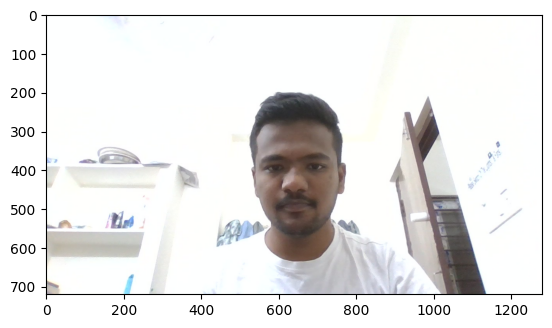

In [3]:
plt.imshow(person)  

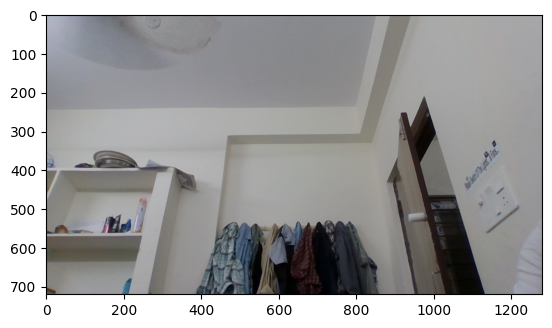

In [4]:
plt.imshow(no_person) 

In [6]:
mask_person=np.zeros((720,1280),dtype=np.uint8)
mask_person[200:750,300:1100]=255

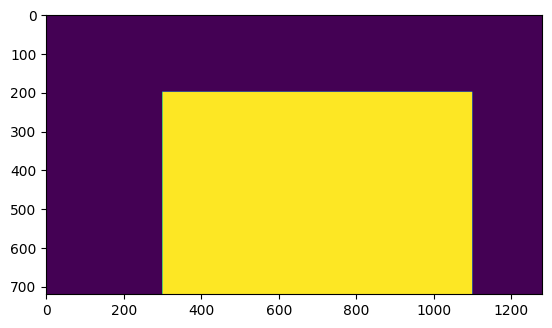

In [7]:
plt.imshow(mask_person)

In [8]:
mask_background=cv2.bitwise_not(mask_person)

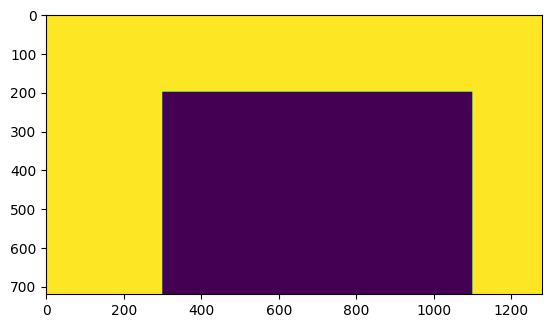

In [9]:
plt.imshow(mask_background)

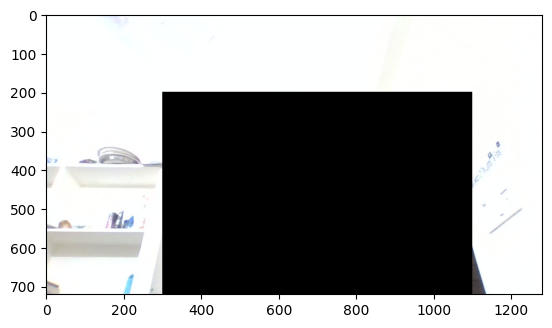

In [10]:
plt.imshow(cv2.bitwise_and(person,person,mask=mask_background)) 

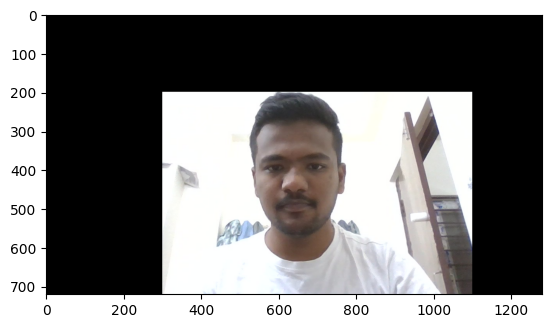

In [11]:
plt.imshow(cv2.bitwise_and(person,person,mask=mask_person)) 

In [14]:
x=cv2.bitwise_and(person,person,mask=mask_background)
y=cv2.bitwise_and(no_person,no_person,mask=mask_person)

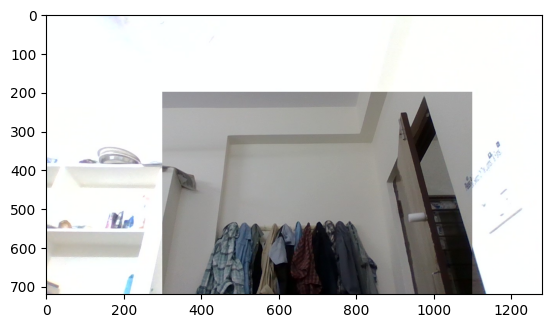

In [15]:
plt.imshow(x+y)